# 🔵 Notebook 02 — Clustering Institucional K-Means
## Segmentación de Instituciones por Perfil de Riesgo/Eficiencia

**Objetivo:** Identificar grupos naturales de instituciones con base en su perfil histórico, para guiar intervenciones diferenciadas.

**Pipeline:** Ejecutar primero `python src/ml/clustering.py` para generar los archivos de salida.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

ML_DIR = 'C:\\Users\\sebas\\OneDrive\\Desktop\\Proyecto_Final_BigDataV\\data\\processed\\ml\\'

# Colores por cluster
CLUSTER_COLORS = {
    0: '#27AE60',   # verde  — alta eficiencia
    1: '#F39C12',   # amarillo — crecimiento acelerado
    2: '#E74C3C',   # rojo   — riesgo académico
    3: '#2980B9',   # azul   — pequeña estable
    4: '#8E44AD',   # morado — alta docencia / baja eficiencia
}

CLUSTER_LABELS = {
    0: '🟢 Alta eficiencia',
    1: '🟡 Crecimiento acelerado',
    2: '🔴 Riesgo académico',
    3: '🔵 Pequeña estable',
    4: '🟠 Alta docencia / baja eficiencia',
}

plt.rcParams.update({
    'figure.facecolor': '#F8F9FA',
    'axes.facecolor':   '#F8F9FA',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})
print('✅ Setup completo')

✅ Setup completo


In [2]:
# ── Cargar resultados del clustering ──────────────────────────────
clusters = pd.read_csv(ML_DIR + 'institutional_clusters.csv')
profiles = pd.read_csv(ML_DIR + 'cluster_profiles.csv')
pca_df   = pd.read_csv(ML_DIR + 'pca_coords.csv')
sil_df   = pd.read_csv(ML_DIR + 'silhouette_scores.csv')

print(f'Instituciones clasificadas: {len(clusters):,}')
print(f'Clusters:                   {clusters["cluster"].nunique()}')
print('\nDistribución:')
print(clusters['cluster_label'].value_counts().to_string())

Instituciones clasificadas: 367
Clusters:                   5

Distribución:
cluster_label
🟡 Crecimiento acelerado              205
🟢 Alta eficiencia                    115
🟠 Alta docencia / baja eficiencia     28
🔴 Riesgo académico                    18
🔵 Pequeña estable                      1


---
## 📊 Visualización 1 — Silhouette Score: K óptimo

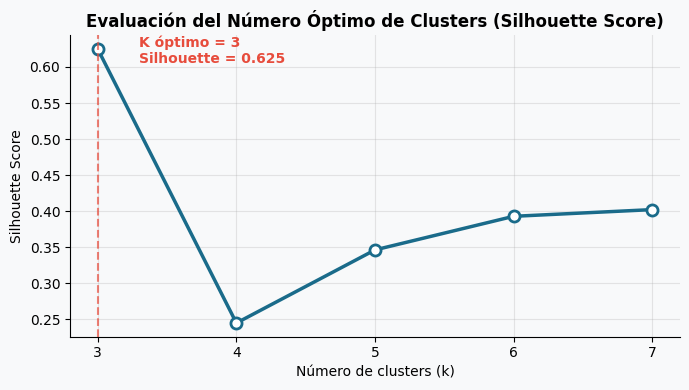

✅ Silhouette guardado


In [3]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(sil_df['k'], sil_df['silhouette'],
        marker='o', linewidth=2.5, color='#1A6B8A',
        markersize=8, markerfacecolor='white', markeredgewidth=2)

best_k = sil_df.loc[sil_df['silhouette'].idxmax()]
ax.axvline(x=best_k['k'], color='#E74C3C', linestyle='--', alpha=0.7)
ax.annotate(f"K óptimo = {int(best_k['k'])}\nSilhouette = {best_k['silhouette']:.3f}",
            xy=(best_k['k'], best_k['silhouette']),
            xytext=(best_k['k'] + 0.3, best_k['silhouette'] - 0.02),
            fontsize=10, color='#E74C3C', fontweight='bold')

ax.set_title('Evaluación del Número Óptimo de Clusters (Silhouette Score)',
             fontweight='bold')
ax.set_xlabel('Número de clusters (k)')
ax.set_ylabel('Silhouette Score')
ax.set_xticks(sil_df['k'])
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(ML_DIR + '..\\aggregations\\viz_cl1_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Silhouette guardado')

---
## 🗺️ Visualización 2 — PCA 2D: Mapa de Clusters Institucionales

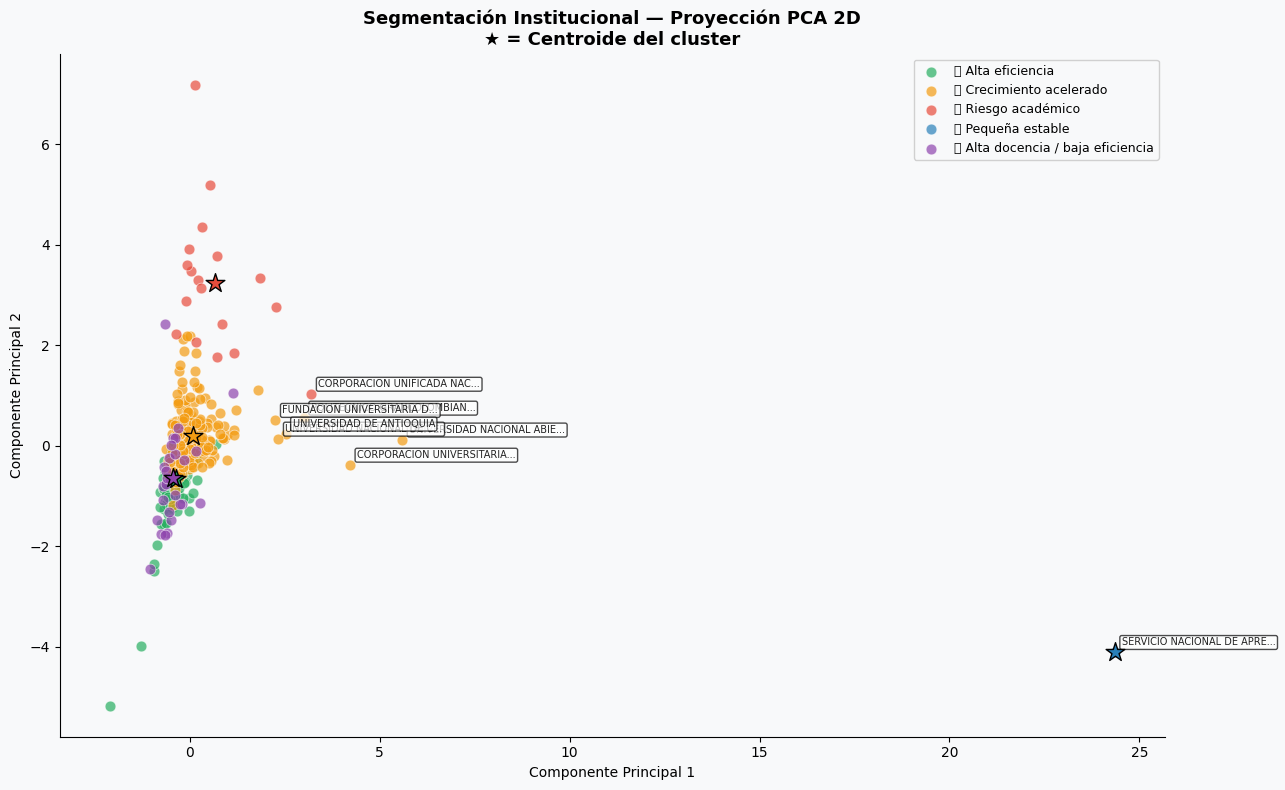

✅ PCA 2D guardado


In [4]:
fig, ax = plt.subplots(figsize=(13, 8))

for cluster_id, group in pca_df.groupby('cluster'):
    color = CLUSTER_COLORS.get(cluster_id, '#888')
    label = CLUSTER_LABELS.get(cluster_id, f'Cluster {cluster_id}')
    ax.scatter(
        group['PC1'], group['PC2'],
        c=color, label=label,
        alpha=0.7, s=60, edgecolors='white', linewidth=0.5
    )

# Anotar las instituciones más grandes (top 8 por matriculados)
if 'MATRICULADOS' in pca_df.columns:
    top_ies = pca_df.nlargest(8, 'MATRICULADOS')
    for _, row in top_ies.iterrows():
        nombre = str(row['NOMBRE_IES'])[:25] + '...' if len(str(row['NOMBRE_IES'])) > 25 else str(row['NOMBRE_IES'])
        ax.annotate(nombre,
                    xy=(row['PC1'], row['PC2']),
                    xytext=(5, 5), textcoords='offset points',
                    fontsize=7, color='#222',
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

# Centroides
centroides = pca_df.groupby('cluster')[['PC1', 'PC2']].mean()
for cluster_id, row in centroides.iterrows():
    color = CLUSTER_COLORS.get(cluster_id, '#888')
    ax.scatter(row['PC1'], row['PC2'], c=color, s=200,
               marker='*', edgecolors='black', linewidth=1, zorder=5)

ax.set_title('Segmentación Institucional — Proyección PCA 2D\n'
             '★ = Centroide del cluster',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Componente Principal 1')
ax.set_ylabel('Componente Principal 2')
ax.legend(loc='upper right', framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.savefig(ML_DIR + '..\\aggregations\\viz_cl2_pca_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ PCA 2D guardado')

---
## 📊 Visualización 3 — Radar / Heatmap de Perfiles de Cluster

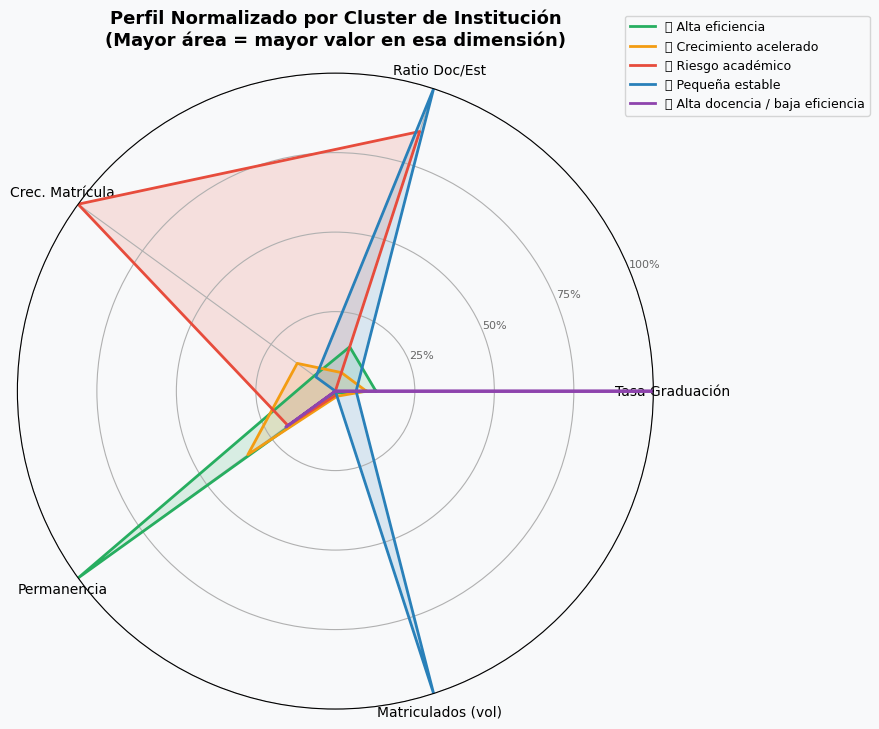

✅ Radar de perfiles guardado


In [5]:
# Seleccionar features relevantes para el perfil
feat_cols = ['avg_tasa_graduacion', 'avg_ratio_docente_estudiante',
             'avg_tasa_crecimiento_matricula', 'avg_tasa_permanencia',
             'avg_MATRICULADOS']
feat_labels = ['Tasa Graduación', 'Ratio Doc/Est', 'Crec. Matrícula',
               'Permanencia', 'Matriculados (vol)']

# Normalizar 0-1 para radar
profile_norm = profiles[feat_cols].copy()
for c in feat_cols:
    mn, mx = profile_norm[c].min(), profile_norm[c].max()
    profile_norm[c] = (profile_norm[c] - mn) / (mx - mn) if mx > mn else 0

profile_norm['cluster'] = profiles['cluster']
profile_norm['cluster_label'] = profiles['cluster_label']

# ── Radar chart ────────────────────────────────────────────────────
N = len(feat_cols)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # cerrar el polígono

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#F8F9FA')

for _, row in profile_norm.iterrows():
    cluster_id = int(row['cluster'])
    color = CLUSTER_COLORS.get(cluster_id, '#888')
    label = CLUSTER_LABELS.get(cluster_id, f'Cluster {cluster_id}')
    values = [row[c] for c in feat_cols]
    values += values[:1]

    ax.plot(angles, values, linewidth=2, color=color, label=label)
    ax.fill(angles, values, alpha=0.15, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(feat_labels, fontsize=10)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(['25%', '50%', '75%', '100%'], fontsize=8, color='#666')
ax.set_ylim(0, 1)

ax.set_title('Perfil Normalizado por Cluster de Institución\n'
             '(Mayor área = mayor valor en esa dimensión)',
             fontweight='bold', fontsize=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=9)

plt.tight_layout()
plt.savefig(ML_DIR + '..\\aggregations\\viz_cl3_radar_perfiles.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Radar de perfiles guardado')

---
## 📋 Visualización 4 — Distribución de clusters por Sector

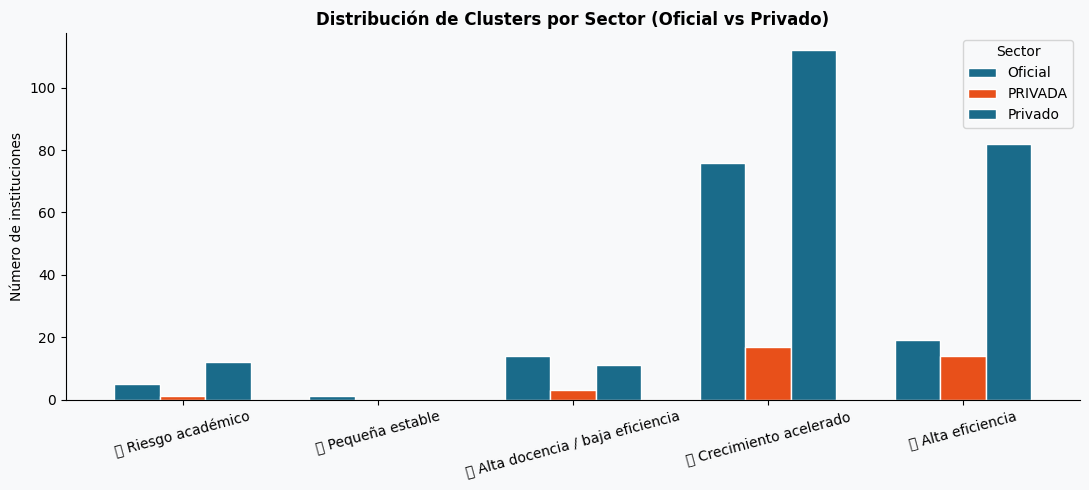


📋 Perfil promedio por cluster:
                    cluster_label  avg_tasa_graduacion  avg_ratio_docente_estudiante  avg_tasa_crecimiento_matricula  avg_tasa_permanencia  avg_brecha_ingreso_egreso  avg_MATRICULADOS
                🟢 Alta eficiencia             0.120494                     14.610777                       -0.025892              5.000785                 772.676087       7411.781739
          🟡 Crecimiento acelerado             0.110525                     12.536098                        0.042224              2.661432                5241.199431      15787.156423
               🔴 Riesgo académico             0.078610                     31.981591                        0.914737              2.109105                3995.227778      11761.516667
                🔵 Pequeña estable             0.100072                     35.434624                       -0.032063              1.455476              488203.000000     777821.500000
🟠 Alta docencia / baja eficiencia             0.

In [6]:
crosstab = pd.crosstab(clusters['cluster_label'], clusters['SECTOR_IES'])

fig, ax = plt.subplots(figsize=(11, 5))
crosstab.plot(kind='bar', ax=ax, color=['#1A6B8A', '#E8501A'],
              edgecolor='white', width=0.7)

ax.set_title('Distribución de Clusters por Sector (Oficial vs Privado)',
             fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Número de instituciones')
ax.tick_params(axis='x', rotation=15)
ax.legend(title='Sector')

plt.tight_layout()
plt.savefig(ML_DIR + '..\\aggregations\\viz_cl4_clusters_sector.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabla de perfiles
print('\n📋 Perfil promedio por cluster:')
display_cols = ['cluster_label'] + [c for c in profiles.columns if 'avg_' in c]
print(profiles[display_cols].to_string(index=False))